# ___Phylogenetic traversal of independent ACEs of discrete and continuous traits___
---------------------------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.5.3 (2026-03-11 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("geiger")
    library("phytools")
    library("corHMM")
    library("ggplot2")
    library("lattice")
    library("latex2exp")
    library("dplyr")
})

source("../helpers.R")
set.seed(2026 - 2 - 24)

## ___Collab subset with 995 species averages (genus level mycorrhizal state recommendations from FungalRoot)___
---------------------------------

In [23]:
data <- read.csv("../../data/chapter2/FREDv3subset/collab_fineroots_log_995_species_means_5states_name_matched_with_phylogeny.csv")[,
                                c("binominal", "F01286", "F01287", "F01289", "F01290", "F00679", "F00727", "state")]

phylogeny <- ape::multi2di(ape::read.tree("../../data/chapter2/uphylomaker/collab_fineroots_log_995_species_means_5states.tre")) # phylogenetic tree created for the 995 species using U.PhyloMaker
stopifnot(all(data$binominal==phylogeny$tip.label)) # make sure the names match

In [4]:
head(data)

,binominal,F01286,F01287,F01289,F01290,F00679,F00727,state
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,Rudbeckia_hirta,Rudbeckia,hirta,Asteraceae,Asterales,-1.3327915,5.694268,AM
2,Ratibida_pinnata,Ratibida,pinnata,Asteraceae,Asterales,-0.8209806,4.025352,AM
3,Heliopsis_helianthoides,Heliopsis,helianthoides,Asteraceae,Asterales,-0.9675840,4.158883,NM
4,Liatris_aspera,Liatris,aspera,Asteraceae,Asterales,-0.7985077,4.382027,AM
5,Arnica_sororia,Arnica,sororia,Asteraceae,Asterales,-1.4134600,4.342257,AM
6,Arnica_fulgens,Arnica,fulgens,Asteraceae,Asterales,-0.6627150,2.765172,AM


## ___ACE of discrete categorical traits using `ape`, `corHMM` & `phytools`___
------------------------------------------------------

In [18]:
#----------------------------------------------------------------------------------------------------------------------------------------------------------
# choosing the ARD model for mycorrhizal state evolution as it has been demonstrated that different transitions happen at different rates
# and some transitions are prectically irreversible compared to others
#----------------------------------------------------------------------------------------------------------------------------------------------------------

# create a named vector for the mycorrhizal states for use with ape::ace and phytools::ancr
states <- setNames(data$state, nm=data$binominal)
stopifnot(all(names(states)==phylogeny$tip.label))

# there are multiple ways to do ACE of discrete characters 
# ace_mystates_rr <- phytools::rerootingMethod(tree = phylogeny, x = states, model = "ARD") - phytools::rerootingMethod method should not be used with non-symmetrical rate models of evolution
# read more here - https://blog.phytools.org/2023/06/decommissioning-rerootingmethod-and.html

# we fit each of these models with all of the three evolutionary modes and will do a model comparsion before making the decision

ace_mystates_hmm_er <- corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", "state")], model = "ER", node.states = "marginal", rate.cat = 1)
ace_mystates_hmm_sym <- corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", "state")], model = "SYM", node.states = "marginal", rate.cat = 1)
ace_mystates_hmm_ard <- corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", "state")], model = "ARD", node.states = "marginal", rate.cat = 1)

 # ape::ace used a non traditional way to compute marginal ACEs, see its documentation for more details
# setting marginal = FALSE actually returns the marginal ACEs, see the documentation of ape::ace for more details
ace_mystates_ape_er <- ape::ace(phy = phylogeny, x = states, type = "discrete", method = "ML", model = "ER", marginal = FALSE)
ace_mystates_ape_sym <- ape::ace(phy = phylogeny, x = states, type = "discrete", method = "ML", model = "SYM", marginal = FALSE)
ace_mystates_ape_ard <- ape::ace(phy = phylogeny, x = states, type = "discrete", method = "ML", model = "ARD", marginal = FALSE)

ace_mystates_ancr_er <- phytools::ancr(phytools::fitMk(tree = phylogeny, x = states, model = "ER"))
ace_mystates_ancr_sym <- phytools::ancr(phytools::fitMk(tree = phylogeny, x = states, model = "SYM"))
ace_mystates_ancr_ard <- phytools::ancr(phytools::fitMk(tree = phylogeny, x = states, model = "ARD"))

save(ace_mystates_hmm_er, ace_mystates_hmm_sym, ace_mystates_hmm_ard,
        ace_mystates_ape_er, ace_mystates_ape_sym, ace_mystates_ape_ard,
        ace_mystates_ancr_er, ace_mystates_ancr_sym, ace_mystates_ancr_ard, file = "./../../data/chapter2/rdata/ace_states_all_995sp.RData")

You specified 'fixed.nodes=FALSE' but included a phy object with node labels. These node labels have been removed.


Warning message in corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", :
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	4	5	
Counts:	778	122	26	20	49	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 
You specified 'fixed.nodes=FALSE' but included a phy object with node labels. These node labels have been removed.


Warning message in corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", :
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	4	5	
Counts:	778	122	26	20	49	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 
You specified 'fixed.nodes=FALSE' but included a phy object with node labels. These node labels have been removed.


Warning message in corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", :
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	4	5	
Counts:	778	122	26	20	49	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 


Warning message in sqrt(diag(solve(h))):
"NaNs produced"
Warning message in ape::ace(phy = phylogeny, x = states, type = "discrete", method = "ML", :
"model fit suspicious: gradients apparently non-finite"


In [5]:
#-----------------------------
# USE THE SAVED MODELS
#-----------------------------

load("../../data/chapter2/rdata/ace_states_all_995sp.RData")

In [6]:
# inspect the fits

corhmm_ace <- list(ER=ace_mystates_hmm_er, SYM=ace_mystates_hmm_sym, ARD=ace_mystates_hmm_ard)
ape_ace <- list(ER=ace_mystates_ape_er, SYM=ace_mystates_ape_sym, ARD=ace_mystates_ape_ard)
phytools_ace <- list(ER=ace_mystates_ancr_er, SYM=ace_mystates_ancr_sym, ARD=ace_mystates_ancr_ard)

## ___Discrete character evolution model comparison___
-----------------------------

In [7]:
# log likelihoods
data.frame(ape = mapply(ape_ace, FUN = function(model) model$loglik), corHMM = mapply(corhmm_ace, FUN = function(model) model$loglik), phytools = mapply(phytools_ace, FUN = function(model) model$logLik))

,ape,corHMM,phytools
,<dbl>,<dbl>,<dbl>
ER,-234.1680,-235.7775,-235.7775
SYM,-424.8496,-225.6099,-225.6099
ARD,-319.5835,-221.4237,-224.0676


In [8]:
# corHMM AICc
mapply(corhmm_ace, FUN = function(model) model$AICc) # SYM seems to have the lowest AICc

ER      SYM      ARD 
473.5590 471.4434 483.7099

In [ ]:
# decide which one to continue with from ER, SYM and ARD?

In [9]:
head(ace_mystates_ape_ard$lik.anc) # ACEs from ape::ace 

,AM,EcM,EcMAM,NM,NMAM
,0.06797624,0.06481560,0.065838641,0.066777925,7.345916e-01
,0.37229626,0.04790564,0.078437869,0.017197780,4.841624e-01
Spermatophyta,0.48629989,0.04681819,0.007496487,0.002356817,4.570286e-01
Mesangiospermae,0.11049100,0.82965758,0.048971350,0.010852400,2.766335e-05
mrcaott2ott121,0.04887689,0.88922165,0.049061369,0.012810141,2.994535e-05
eudicotyledons,0.00323965,0.96555828,0.025870145,0.005304002,2.792034e-05


In [10]:
head(ace_mystates_ancr_ard$ace) # ACEs from phytools::ancr

,AM,EcM,EcMAM,NM,NMAM
996,0.7646277,1.429946e-03,3.098787e-03,0,2.308435e-01
997,0.7933391,8.725995e-04,1.326287e-03,0,2.044621e-01
998,0.9263574,8.199777e-03,3.281847e-04,0,6.511465e-02
999,0.9999998,1.727928e-08,1.238550e-08,0,1.759872e-07
1000,0.9999999,4.519288e-09,6.039789e-09,0,7.104000e-08
1001,0.9999998,9.471083e-09,2.813316e-08,0,1.516052e-07


In [11]:
head(ace_mystates_hmm_ard$states) # ACEs from corHMM

"(1,R1)","(2,R1)","(3,R1)","(4,R1)","(5,R1)"
0.8825937,2.155776e-03,1.149974e-02,3.914549e-04,1.033593e-01
0.8950313,1.502371e-03,1.159598e-02,1.196870e-04,9.175062e-02
0.9488643,8.373669e-03,1.271708e-02,6.990298e-05,2.997501e-02
0.9998987,2.133221e-08,1.011949e-04,4.482838e-09,1.072578e-07
0.9999054,6.640493e-09,9.455386e-05,1.971251e-09,4.657252e-08
0.9999294,1.508447e-08,7.022760e-05,1.839560e-07,1.428319e-07


In [7]:
# the output of corHMM lacks explicit column names (mycorrhizal states) but outputs of ape and corHMM lack explicit row names (node numbers)

In [13]:
ace_mystates_hmm_ard


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -221.4237 482.8475 483.7099        1  995

Legend
      1       2       3       4       5 
   "AM"   "EcM" "EcMAM"    "NM"  "NMAM" 

Rates
             (1,R1)       (2,R1)       (3,R1)       (4,R1)       (5,R1)
(1,R1)           NA 0.0002014036 0.0002165938 0.0002218301 0.0007887247
(2,R1) 0.0007754451           NA 0.0000000010 0.0000000010 0.0000000010
(3,R1) 0.0142958645 0.0000000010           NA 0.0000000010 0.0000000010
(4,R1) 0.0006245918 0.0000000010 0.0000000010           NA 0.0000000010
(5,R1) 0.0011454499 0.0007787474 0.0000000010 0.0000000010           NA

Arrived at a reliable solution 

In [8]:
# based on the legend of the corHMM model output
STATES_LEGEND_CORHMM <- c("AM", "AMEcM", "AMNM", "EcM", "ErM", "NM")
STATES_LEGEND_CORHMM

[1] "AM"    "AMEcM" "AMNM"  "EcM"   "ErM"   "NM"

In [9]:
state_preds_hmm <- STATES_LEGEND_CORHMM[apply(ace_mystates_hmm$states, MARGIN = 1, FUN = which.max)] # MARGIN = 1 is used for row wise apply

# colnames(ace_mystates_ancr$ace)
state_preds_phy <- colnames(ace_mystates_ancr$ace)[apply(ace_mystates_ancr$ace, MARGIN = 1, FUN = which.max)] # only the output of phytools::ancr has explicit node numbers as row names!!

# colnames(ace_mystates_ape$lik.anc)
state_preds_ape <- colnames(ace_mystates_ape$lik.anc)[apply(ace_mystates_ape$lik.anc, MARGIN = 1, FUN = which.max)]

In [10]:
mean(state_preds_ape == state_preds_hmm)

[1] 0.9720812

In [11]:
mean(state_preds_ape == state_preds_phy) # the lowest

[1] 0.9492386

In [12]:
mean(state_preds_phy == state_preds_hmm) # the highest

[1] 0.9771574

In [13]:
all(rownames(ace_mystates_ancr$ace) == 396:789) # internal node names

[1] TRUE

## ___ACE of continuous traits___
------------------------------------------------------

In [15]:
RD <- setNames(data$F00679, nm = data$binominal)
SRL <- setNames(data$F00727, nm = data$binominal)

# phytools::fastAnc uses a brownian motion (BM) model for continuous trait evolution

ace_srl_fastanc <- phytools::fastAnc(tree = phylogeny, x = SRL, vars = TRUE, CI = TRUE) # this is a Maximim Likelihood (ML) based method - Brownian motion models which essentially is a Markov process on a continuous scale
# https://eeob-macroevolution.github.io/Practicals/Ancestral_State_Estimation/AncStateEstimation_Tutorial.html
# the link above provides detailed info on ACE, and also recommends incorporating fossil data when available to make the ACE more rigorous
# do we have fossil root trait data???????

# Liam J. Revell's website says that phytools::fastAnc also uses Felsenstein's re-rooting algorithm for ACE of continuous characters - http://www.phytools.org/Cordoba2017/ex/7/Anc-states-continuous.html
# PCMIR (page 224) recommends fitting phytools::fastAnc with vars=TRUE, CI=TRUE as ACE happens with lots of uncertainty, so it's important to know the CIs of each reconstruction
ace_rd_fastanc <- phytools::fastAnc(tree = phylogeny, x = RD, vars = TRUE, CI = TRUE) # repeat the above for RD

In [16]:
# examine the variances and confidence intervals of the ACE of the continuous trait
head(ace_srl_fastanc$CI95)

996,-3.153054,10.667221
997,-2.825290,10.326407
998,-2.421623,9.453410
999,1.526475,5.618044
1000,1.540070,5.616640
1001,1.663560,5.637984


In [17]:
# see if the ACEs fall within the respective 95% CIs (BUT THESE 95% CIs ARE REALLY BROAD?????)
mean(ace_srl_fastanc$CI95[, 2] >= ace_srl_fastanc$ace) # estimates lesses than or equal to the upper bound
mean(ace_srl_fastanc$CI95[, 1] <= ace_srl_fastanc$ace) # estimates greater than or equal to the lower bound

[1] 1

[1] 1

In [18]:
# check the 95% CIs for RD
mean(ace_rd_fastanc$CI95[, 1] <= ace_rd_fastanc$ace) # lower bound <= ACE
mean(ace_rd_fastanc$CI95[, 2] >= ace_rd_fastanc$ace) # upper bound >= ACE

[1] 1

[1] 1

In [19]:
# however phytools::fastAnc models the continuous trait evolution based on a BM process, since hOUwie models it based on an OU process, it'll be helpful to include that too
# http://www.phytools.org/anthrotree/asr/1/
# Lapack routine dgesv: system is exactly singular: U[1013,1013] = 0 - this happens when there are 0 length branches in the phylogeny
# https://github.com/liamrevell/phytools/issues/89

phytools::anc.ML(tree = phylogeny, model = "OU", x = RD, maxit = 5000)

ERROR: Error in solve.default(C): Lapack routine dgesv: system is exactly singular: U[1013,1013] = 0


In [88]:
# stats::cophenetic(phylogeny)

In [20]:
sum(phylogeny$edge.length <= 0) # damn!!!

[1] 91

In [21]:
edge_length_adjusted_phylogeny <- phylogeny # create a copy
edge_length_adjusted_phylogeny$edge.length[edge_length_adjusted_phylogeny$edge.length <= 0] <- 1e-10 # replace zeroes with a single small positive value
phytools::anc.ML(tree = edge_length_adjusted_phylogeny, model = "OU", x = RD, maxit = 5000) # try again

ERROR: Error in solve.default(C): system is computationally singular: reciprocal condition number = 3.13435e-17


In [22]:
# replacing all the zeroes with one small positive number gave a different error - system is computationally singular: reciprocal condition number = 3.1331e-17
# try using a vector of random positive numbers

replacement_lengths <- rnorm(n=sum(phylogeny$edge.length <= 0), mean = 1.0, sd = 0.05) * 1e-10
stopifnot(all(replacement_lengths > 0))

edge_length_adjusted_phylogeny <- phylogeny
edge_length_adjusted_phylogeny$edge.length[edge_length_adjusted_phylogeny$edge.length <= 0] <- replacement_lengths
phytools::anc.ML(tree = edge_length_adjusted_phylogeny, model = "OU", x = RD, maxit = 5000)

ERROR: Error in solve.default(C): system is computationally singular: reciprocal condition number = 3.0889e-17


In [24]:
# try using the package geiger instead of phytools
# which allows the following models  - "BM","OU","EB","rate_trend","lambda","kappa","delta","mean_trend","white"
# page 98 on wards in Phylogenetic Comparative Methods in R

ace_rd_geiger_BM <- geiger::fitContinuous(phy = phylogeny, dat = RD, model = "BM")
ace_rd_geiger_EB <- geiger::fitContinuous(phy = phylogeny, dat = RD, model = "EB")
ace_rd_geiger_OU <- geiger::fitContinuous(phy = phylogeny, dat = RD, model = "OU")

In [50]:
# inspect the fits

as.data.frame(cbind(BM = c(alpha=NA, ace_rd_geiger_BM$opt), # BM models do not estimate alpha, hence we manually include to match the rows with other model types
                    OU = ace_rd_geiger_OU$opt, EB = ace_rd_geiger_EB$opt))

,BM,OU,EB
,<named list>,<named list>,<named list>
alpha,NA,0.357751,-1.000002e-06
sigsq,0.02521209,0.1556148,0.02522221
z0,-0.9195616,-1.100825,-0.919559
lnL,-1066.482,-614.9794,-1066.49
method,Brent,L-BFGS-B,subplex
k,2,3,3
aic,2136.963,1235.959,2138.979
aicc,2136.976,1235.983,2139.004


In [ ]:
# when alpha of a EB model is close to 0.00, the EB model becomes a constant rate BM model
# the model with the lowest AICc is OU, which is great as the hOUwie models also use the OU process to model the continuous trait evolution

In [55]:
# now, repeat all of this for SRL

ace_srl_geiger_BM <- geiger::fitContinuous(phy = phylogeny, dat = SRL, model = "BM")
ace_srl_geiger_EB <- geiger::fitContinuous(phy = phylogeny, dat = SRL, model = "EB") # when you get a "Parameter estimates appear at bounds:	a" warning message, this happens when the alpha is very close to 0.0
# this is okay, and just means BM will be a better fit than the EB model in this case
ace_srl_geiger_OU <- geiger::fitContinuous(phy = phylogeny, dat = SRL, model = "OU")

as.data.frame(cbind(BM = c(alpha=NA, ace_srl_geiger_BM$opt), OU = ace_srl_geiger_OU$opt, EB = ace_srl_geiger_EB$opt))

,BM,OU,EB
,<named list>,<named list>,<named list>
alpha,NA,0.3930998,-1.000009e-06
sigsq,0.1745954,1.068359,0.1746657
z0,3.757083,3.890931,3.757091
lnL,-2029.218,-1529.779,-2029.226
method,Brent,L-BFGS-B,subplex
k,2,3,3
aic,4062.436,3065.557,4064.452
aicc,4062.448,3065.581,4064.476


In [ ]:
# once again, OU seems to be the best fit, which is convenient.

## $\delta{t}=log(t_{ancestor})-log(t_{descendant})$

In [2]:
traitdata <- read.csv("../../data/chapter2/FREDv3subset/collab_fineroots_log_995_species_means_5states.csv", stringsAsFactors = TRUE) # LOG TRANSFORMED CONTINUOUS TRAIT VALUES
phylogeny <- ape::multi2di(ape::read.tree("../../data/chapter2/uphylomaker/collab_fineroots_log_995_species_means_5states.tre"))
traitdata <- traitdata[match(phylogeny$tip.label, traitdata$binominal), ]

stopifnot(traitdata$binominal == phylogeny$tip.label)

In [3]:
traitdata[, c("binominal", "state")] |> head()

,binominal,state
,<fct>,<fct>
826,Rudbeckia_hirta,AM
802,Ratibida_pinnata,AM
468,Heliopsis_helianthoides,NM
526,Liatris_aspera,AM
104,Arnica_sororia,AM
103,Arnica_fulgens,AM


In [4]:
table(traitdata$state) # mycorrhizal state diversity


   AM   EcM EcMAM    NM  NMAM 
  778   122    26    20    49 

In [7]:
#---------------------------------------------------------------------------------------------------------------------
# bofore that test for phylogenetic signal in continuous traits using Bloombergs K test and Pagel's lambda test
#---------------------------------------------------------------------------------------------------------------------

In [8]:
# in Bloomberg's K test, phylogenetic signal is considered high when variance between clades is lesser than the variance within clades
# K = 1.000 indicates Brownian motion based evolution

In [9]:
# do we see a phylogenetic signal???
bberg_rd <- phytools::phylosig(tree = phylogeny, x = setNames(traitdata$F00679, nm = traitdata$binominal), test = TRUE, nsim = 10000)
bberg_srl <- phytools::phylosig(tree = phylogeny, x = setNames(traitdata$F00727, nm = traitdata$binominal), test = TRUE, nsim = 10000)


Phylogenetic signal K : 0.0293936 
P-value (based on 10000 randomizations) : 1e-04 


In [ ]:
print(bberg_rd, bberg_srl)

In [105]:
# now using Pagel's lambda tests
# lambda < 1 means that less phylogenetic signal than expected under a Brownian motion model of evolution

pagels_rd <- phytools::phylosig(tree = phylogeny, x = setNames(rd1005$RD, nm = rd1005$binominal), method = "lambda", test = TRUE)
pagels_rd


Phylogenetic signal lambda : 0.764027 
logL(lambda) : -548.524 
LR(lambda=0) : 228.76 
P-value (based on LR test) : 1.11121e-51 


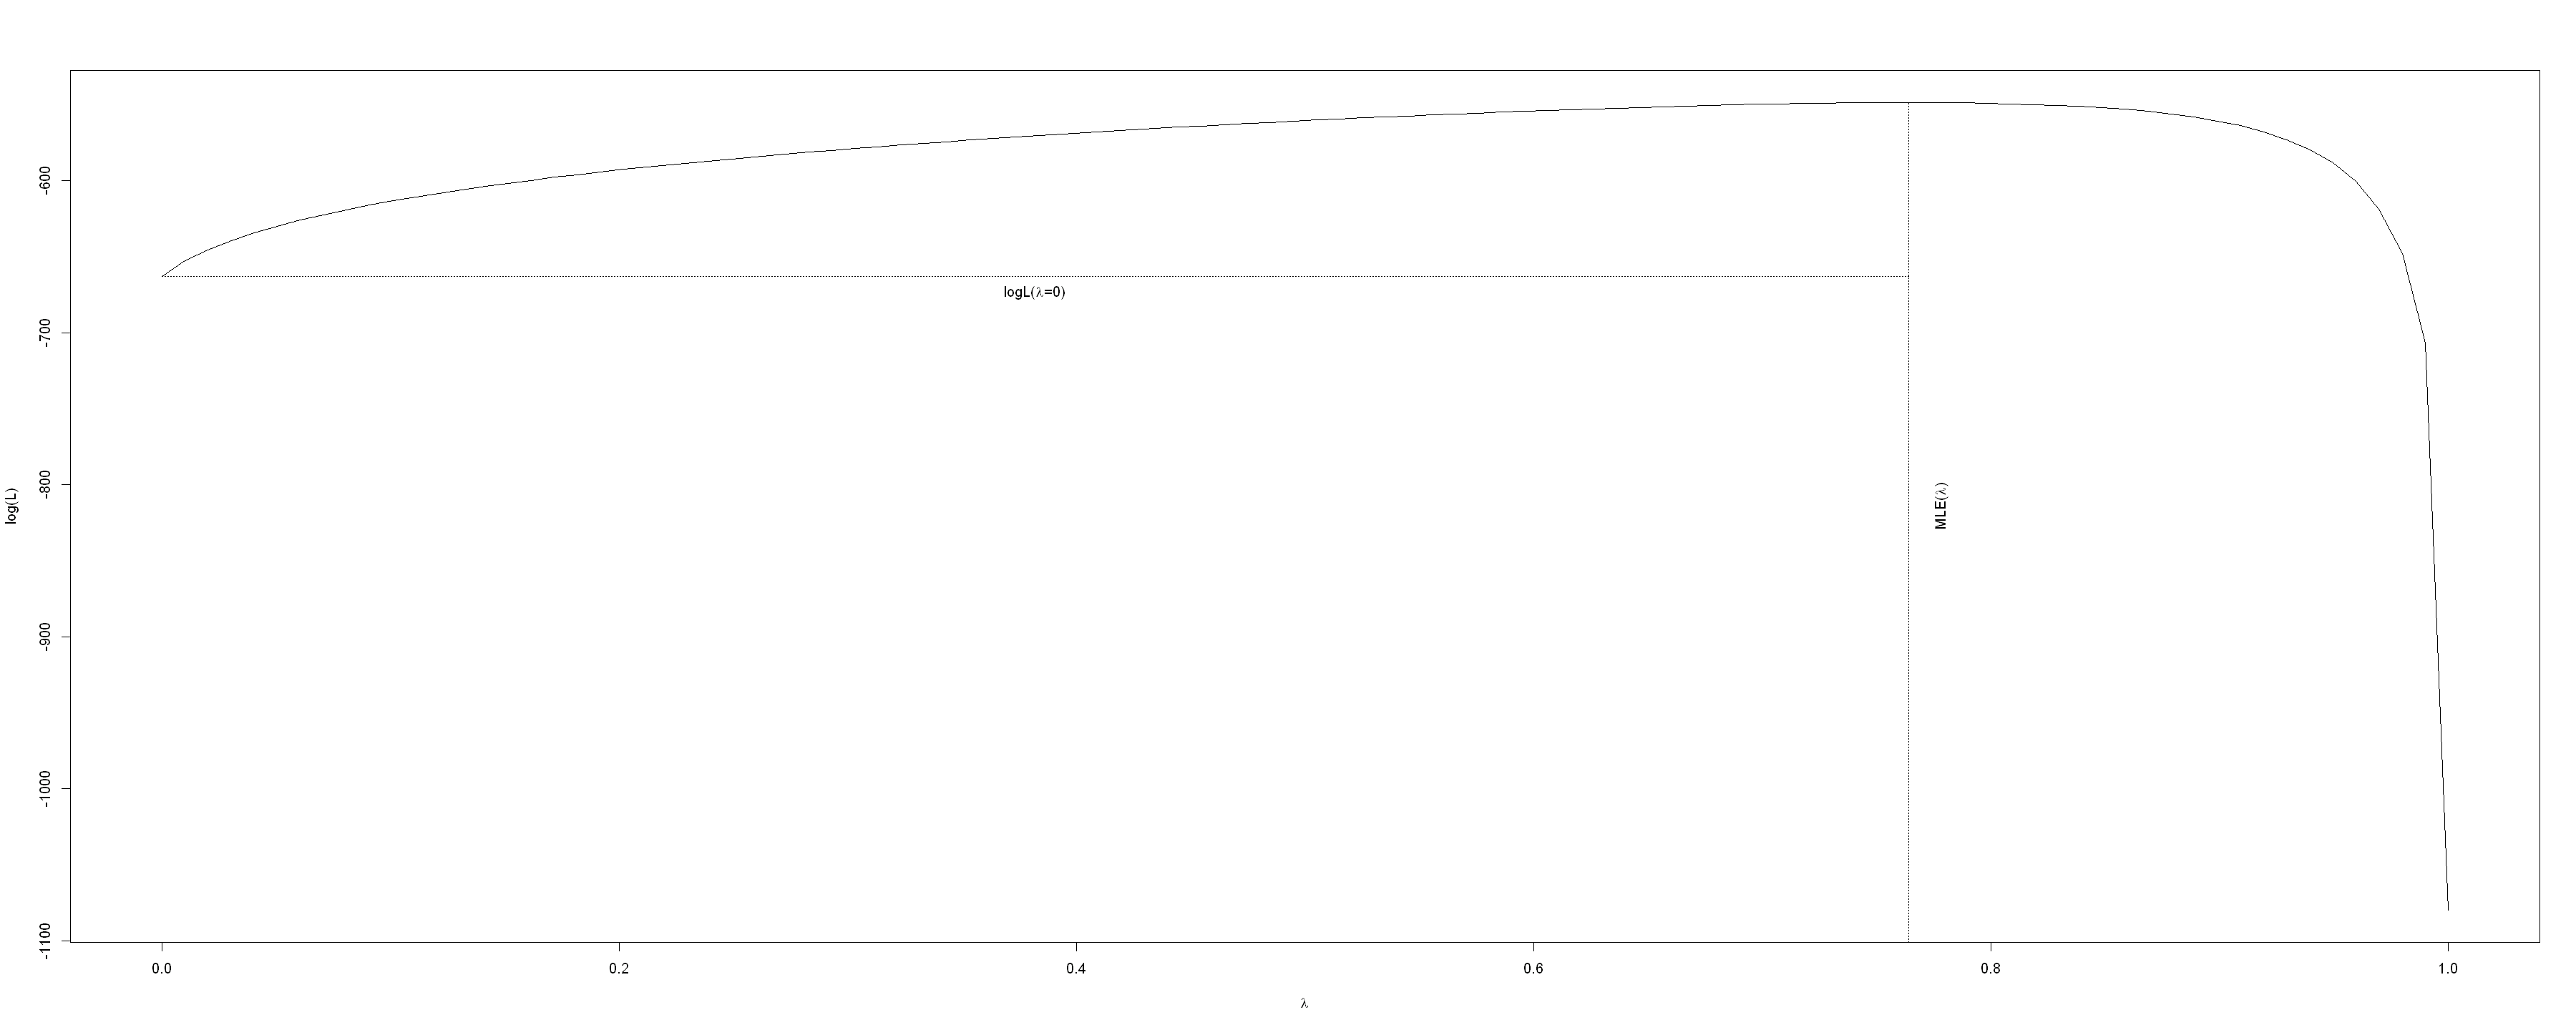

In [106]:
plot(pagels_rd)

In [107]:
pagels_srl <- phytools::phylosig(tree = phylogeny, x = setNames(srl1005$SRL, nm = srl1005$binominal), method = "lambda", test = TRUE)
pagels_srl


Phylogenetic signal lambda : 0.699249 
logL(lambda) : -1480.39 
LR(lambda=0) : 207.026 
P-value (based on LR test) : 6.11896e-47 


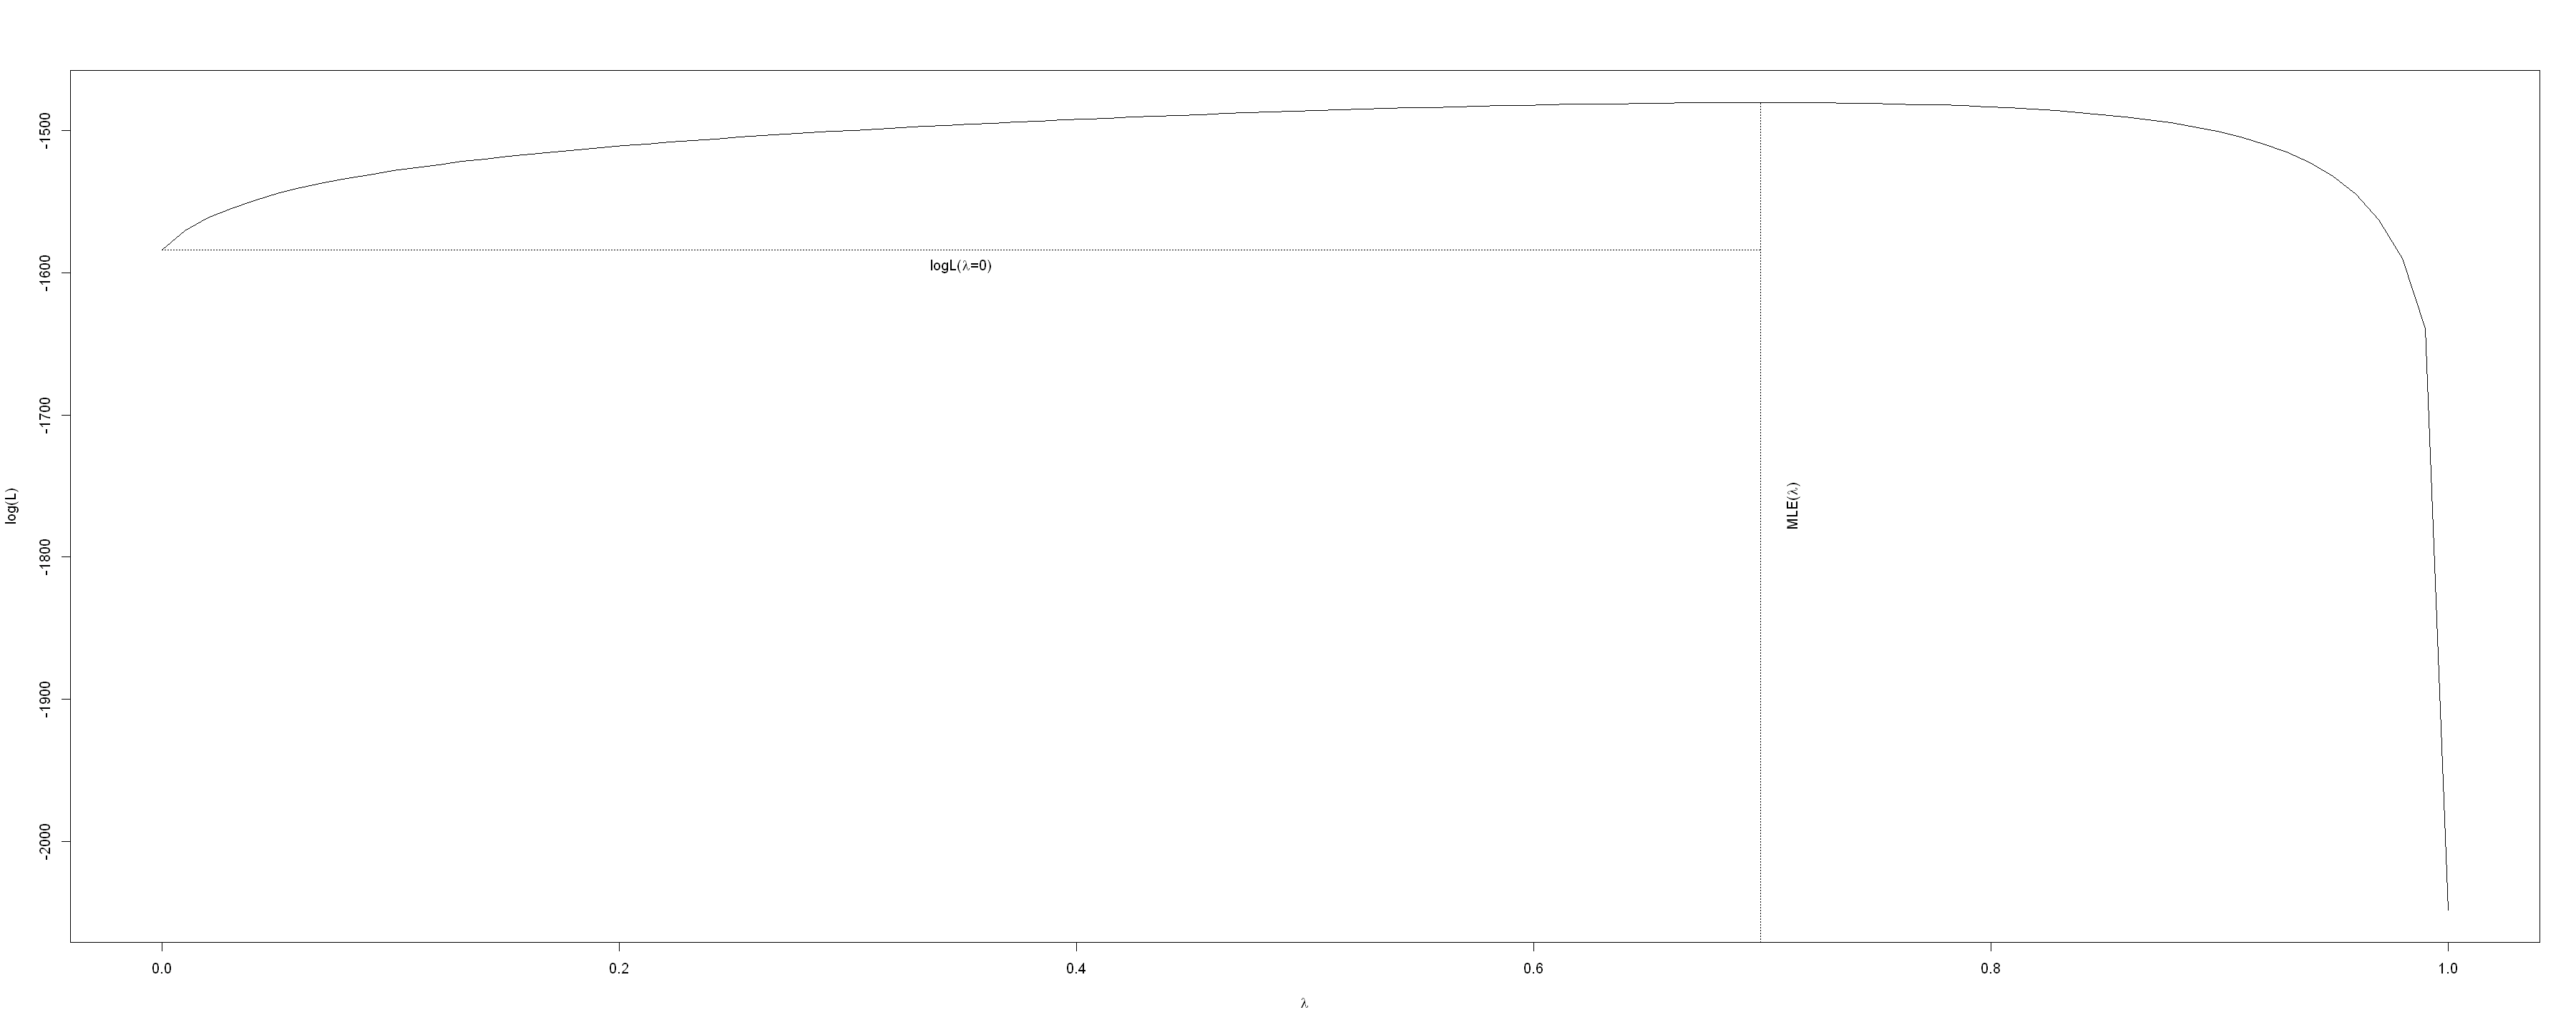

In [108]:
plot(pagels_srl)

In [ ]:
ace_rd_995 <- phytools::fastAnc(tree = phylogeny, x = setNames(object = traitdata$F00679, nm = traitdata$binominal), vars = TRUE, CI = TRUE) # ACE for RD
ace_srl_995 <- phytools::fastAnc(tree = phylogeny, x = setNames(object = traitdata$F00727, nm = traitdata$binominal), vars = TRUE, CI = TRUE) # ACE for SRL

ace_5states_995_corhmm <- corHMM::corHMM(phy = phylogeny, data = traitdata[, c("binominal", "state")], model = "ARD", node.states = "marginal", rate.cat = 1)
ace_5states_995_ape <- ape::ace(phy = phylogeny, x = setNames(object = traitdata$state, nm = traitdata$binominal), type = "discrete", method = "ML", model = "ARD", marginal = FALSE) # ape::ace used a non traditional way to compute marginal ACEs, see its documentation for more details
ace_5states_995_phytools <- phytools::ancr(phytools::fitMk(tree = phylogeny, x = setNames(object = traitdata$state, nm = traitdata$binominal), model = "ARD"))

save(ace_rd_995, ace_srl_995, ace_5states_995_corhmm, ace_5states_995_ape, ace_5states_995_phytools, file = "../rdata/IndependentACEs995sp5statesLog.RData")

In [6]:
load("../../data/chapter2/rdata/IndependentACEs995sp5statesLog.RData") # ACES of continuous traits were done using log transformed trait values (RD, SRL)

In [7]:
# compare the discrete ACEs
# all ACE tables have columns in the following order => # AM	EcM	EcMAM	NM	NMAM

mean(apply(ace_5states_995_ape$lik.anc, MARGIN = 1, FUN = which.max)  == apply(ace_5states_995_corhmm$states, MARGIN = 1, FUN = which.max))
mean(apply(ace_5states_995_ape$lik.anc, MARGIN = 1, FUN = which.max)  == apply(ace_5states_995_phytools$ace, MARGIN = 1, FUN = which.max))
mean(apply(ace_5states_995_corhmm$states, MARGIN = 1, FUN = which.max) == apply(ace_5states_995_phytools$ace, MARGIN = 1, FUN = which.max))

[1] 0.9657948

[1] 0.9607646

[1] 0.9949698

In [8]:
phylogeny # 995 tips and 994 internal nodes


Phylogenetic tree with 995 tips and 994 internal nodes.

Tip labels:
  Rudbeckia_hirta, Ratibida_pinnata, Heliopsis_helianthoides, Liatris_aspera, Arnica_sororia, Arnica_fulgens, ...
Node labels:
  , , Spermatophyta, Mesangiospermae, mrcaott2ott121, eudicotyledons, ...

Rooted; includes branch length(s).

In [9]:
ace_5states_995_corhmm


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -221.4237 482.8474 483.7099        1  995

Legend
      1       2       3       4       5 
   "AM"   "EcM" "EcMAM"    "NM"  "NMAM" 

Rates
             (1,R1)       (2,R1)       (3,R1)       (4,R1)       (5,R1)
(1,R1)           NA 0.0002014373 0.0002166429 0.0002218101 0.0007887831
(2,R1) 0.0007754370           NA 0.0000000010 0.0000000010 0.0000000010
(3,R1) 0.0142979100 0.0000000010           NA 0.0000000010 0.0000000010
(4,R1) 0.0006245473 0.0000000010 0.0000000010           NA 0.0000000010
(5,R1) 0.0011455450 0.0007783447 0.0000000010 0.0000000010           NA

Arrived at a reliable solution 

In [10]:
CORHMM_5STATES_LEGEND <- c("AM", "EcM", "EcMAM", "NM", "NMAM")

In [11]:
paired_changes <- paired_dc_changes(phylogeny = phylogeny,
                                    rdextant = setNames(traitdata$F00679, nm = traitdata$binominal),
                                    srlextant = setNames(traitdata$F00727, nm = traitdata$binominal),
                                    discextant = setNames(traitdata$state, nm = traitdata$binominal),
                                    rdinternodes = ace_rd_995$ace,
                                    srlinternodes = ace_srl_995$ace,
                                    discprobinternodes = ace_5states_995_corhmm$states,
                                    discstates = CORHMM_5STATES_LEGEND)

In [12]:
head(paired_changes)

,shifts,delta_rd,delta_srl
,<chr>,<dbl>,<dbl>
1,AM_to_AM,0.002480619,0.006524816
2,AM_to_AM,-0.054448123,0.234665175
3,AM_to_AM,0.031589377,-0.056366143
4,AM_to_AM,0.003543559,-0.006095365
5,AM_to_AM,0.070699188,-0.072416572
6,AM_to_AM,0.020077742,-0.013665562


In [14]:
write.csv(paired_changes, file = "../../data/chapter2/FREDv3subset/deltalogaces995.csv", row.names = FALSE)

In [10]:
#----------------------------------------------------------------------
# CHANGES IN LOG RD WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

# the continuous trait change measured here is the (value of ancestor - value of descendant)
as.data.frame(lapply(split(paired_changes, ~shifts), FUN = function(df) { c(mean(df$delta_rd), sd(df$delta_rd)) }), row.names = c("mean", "std")) # summary

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_NM,AM_to_NMAM,EcM_to_AM,EcM_to_EcM,EcM_to_NMAM,EcMAM_to_AM,EcMAM_to_EcMAM,NM_to_NM,NMAM_to_AM,NMAM_to_EcM,NMAM_to_NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,-0.00227363,0.001977551,-0.09102003,0.1945589,-0.009203943,0.00842402,0.001767719,0.3076190,0.1672044,0.0122208,0.009987086,-0.03364303,-0.28515146,0.01754058
std,0.24112662,0.277641482,0.37549041,0.3912832,0.301737926,NA,0.239752664,0.0653178,0.5360357,0.2559199,0.167460652,NA,0.07965926,0.27796834


In [11]:
#----------------------------------------------------------------------
# CHANGES IN LOG SRL WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

as.data.frame(lapply(split(paired_changes, ~shifts), FUN = function(df) { c(mean(df$delta_srl), sd(df$delta_srl)) }), row.names = c("mean", "std")) # summary

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_NM,AM_to_NMAM,EcM_to_AM,EcM_to_EcM,EcM_to_NMAM,EcMAM_to_AM,EcMAM_to_EcMAM,NM_to_NM,NMAM_to_AM,NMAM_to_EcM,NMAM_to_NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,0.008940855,-0.02763368,0.4077492,-0.6446742,-0.1191378,0.05997439,-0.002312536,-0.4825296,-0.6171524,-0.05245372,-0.03312823,-0.08856933,0.7096372,-0.05777951
std,0.640810457,1.03544743,1.1579731,0.8756583,0.8972301,NA,0.462535553,2.3073945,1.8795482,0.55928409,0.29958555,NA,0.2485537,1.09449431


In [ ]:

# CONSIDER A VIOLIN PLOT INSTEAD OF REGULAR BOX PLOTS!!!!!!


In [40]:
sample_size_positions <- paired_changes %>% group_by(shifts) %>% summarize(n = n(), delta_rd = max(delta_rd) + 0.1, delta_srl = max(delta_srl) + 0.25)

In [50]:
options(repr.plot.width = 20, repr.plot.height = 12)
plotrd <- ggplot2::ggplot(paired_changes, aes(x = shifts, y = delta_rd, fill = factor(shifts))) +
    # geom_boxplot(outlier.color = "red", outlier.size = 3) +
    stat_boxplot(geom = "errorbar") +
    geom_violin(drop = FALSE, alpha = 0.65) +
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90),
          # using bg="transparent" inside ggsave() alone isn't enough to get a transparent bg, each element seems to be explicitly set to have a transparent bg for that to take effect
          # otherwise the plot gets saved with the default bg not a with a transparent one
          # https://www.r-bloggers.com/2022/07/ggplot2-transparent-background-quick-guide/
    panel.background = element_rect(fill='transparent'), #transparent panel bg
    plot.background = element_rect(fill='transparent', color=NA), #transparent plot bg
    panel.grid.major = element_blank(), #remove major gridlines
    panel.grid.minor = element_blank(), #remove minor gridlines
    legend.background = element_rect(fill='transparent'), #transparent legend bg
    legend.box.background = element_rect(fill='transparent') #transparent legend panel) 
    ) +    
    ylab(unname(latex2exp::TeX(r"($\Delta log(RD)$)"))) +
    xlab("Directional state transitions") + 
    geom_text(aes(label = paste0("n=", n)), data = sample_size_positions, size = 5)

# plot(plotrd)
ggsave(plot = plotrd, filename = "../../plots/DeltaLogRDvsStates.png", height = 16, width = 20, units = "in", dpi = 1000, bg = "transparent")

Warning message:
"Cannot compute density for groups with fewer than two datapoints."


In [48]:
plotsrl <- ggplot2::ggplot(data = paired_changes, aes(x = shifts, y = delta_srl, fill = factor(shifts))) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90),
    panel.background = element_rect(fill='transparent'), #transparent panel bg
    plot.background = element_rect(fill='transparent', color=NA), #transparent plot bg
    panel.grid.major = element_blank(), #remove major gridlines
    panel.grid.minor = element_blank(), #remove minor gridlines
    legend.background = element_rect(fill='transparent'), #transparent legend bg
    legend.box.background = element_rect(fill='transparent') #transparent legend panel
    ) + 
    # geom_boxplot(outlier.color = "red", outlier.size = 3) +
    stat_boxplot(geom = "errorbar", color = "black") +
    geom_violin(drop = FALSE, alpha = 0.65) +
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    ylab(unname(latex2exp::TeX(r"($\Delta log(SRL)$)"))) +
    xlab("Directional state transitions") +
    geom_text(aes(label = paste0("n=", n)), data = sample_size_positions, size = 5)

# plot(plotsrl)
ggsave(plot = plotsrl, filename = "../../plots/DeltaLogSRLvsStates.png", height = 16, width = 20, units = "in", dpi = 1000, bg = "transparent")

Warning message:
"Cannot compute density for groups with fewer than two datapoints."


In [23]:
head(paired_changes)

,shifts,delta_rd,delta_srl
,<chr>,<dbl>,<dbl>
1,AM_to_AM,0.002480619,0.006524816
2,AM_to_AM,-0.054448123,0.234665175
3,AM_to_AM,0.031589377,-0.056366143
4,AM_to_AM,0.003543559,-0.006095365
5,AM_to_AM,0.070699188,-0.072416572
6,AM_to_AM,0.020077742,-0.013665562


In [26]:
# we need to convert the the dataset to a long format
long_format <- data.frame(shifts=c(paired_changes$shifts, paired_changes$shifts), delta=c(paired_changes$delta_rd, paired_changes$delta_srl), trait=c(rep("RD", times = length(paired_changes$delta_rd)),
                    rep("SRL", times = length(paired_changes$delta_srl))))

In [27]:
head(long_format)

,shifts,delta,trait
,<chr>,<dbl>,<chr>
1,AM_to_AM,0.002480619,RD
2,AM_to_AM,-0.054448123,RD
3,AM_to_AM,0.031589377,RD
4,AM_to_AM,0.003543559,RD
5,AM_to_AM,0.070699188,RD
6,AM_to_AM,0.020077742,RD


Warning message:
"Cannot compute density for groups with fewer than two datapoints."


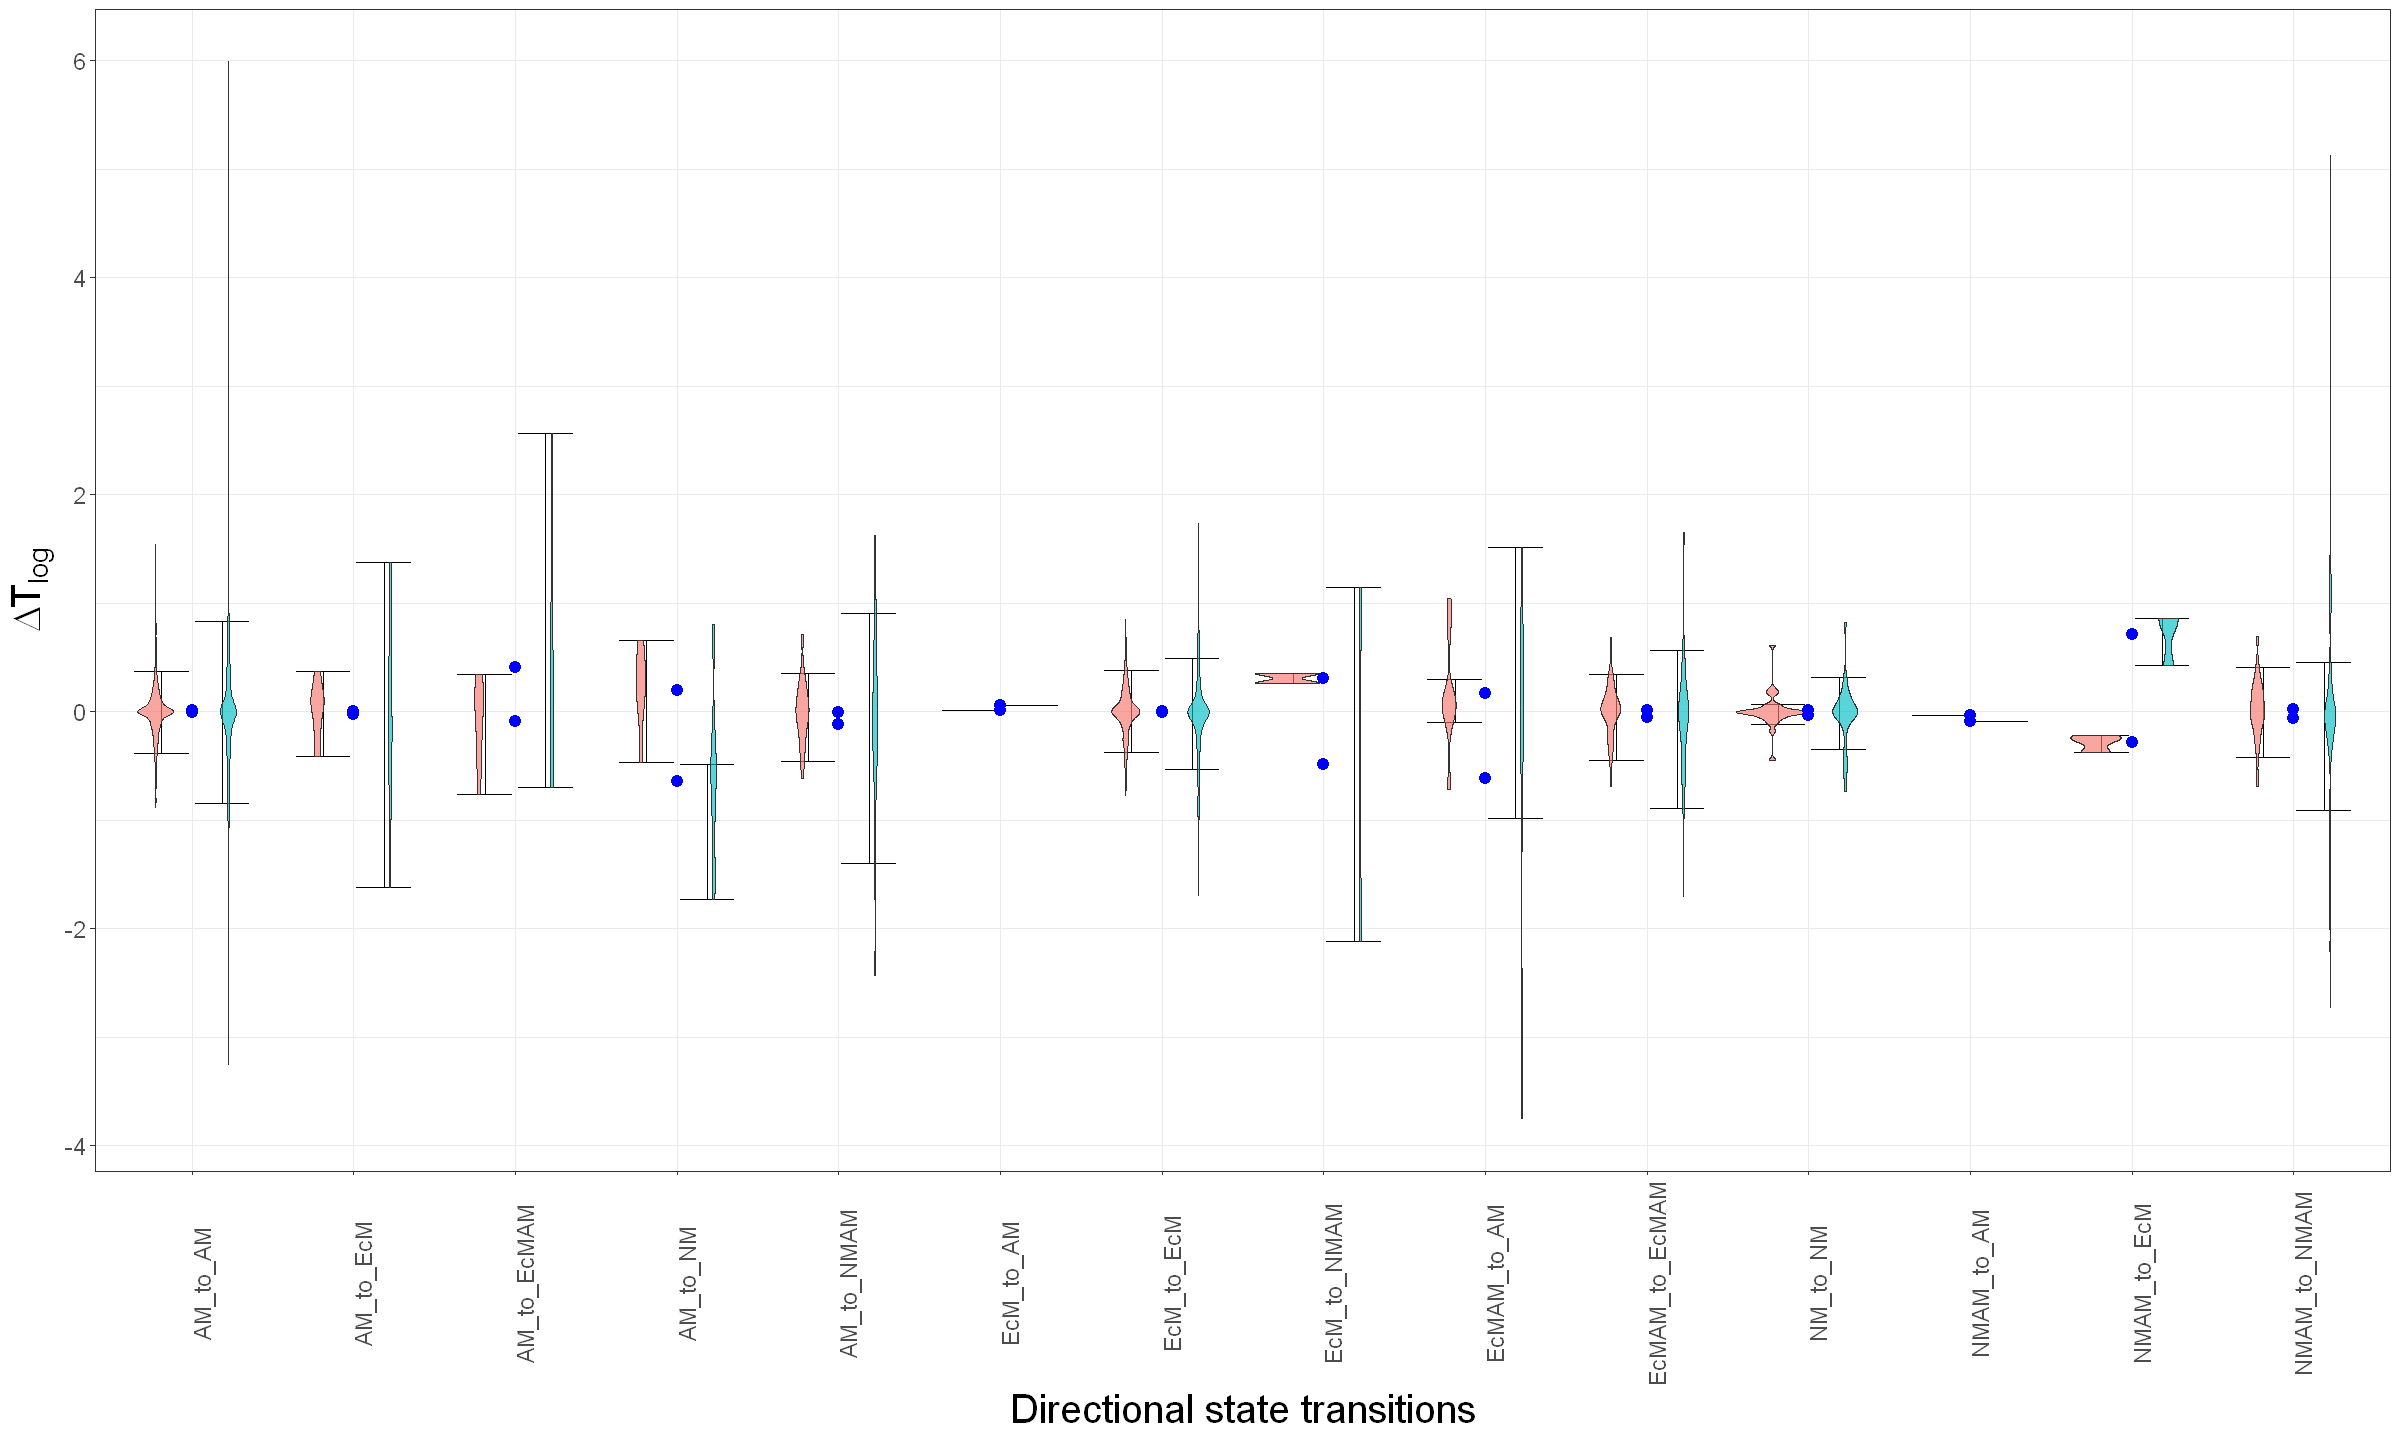

In [44]:
# this is a bad idea - delta log(SRL) and delta log(RD) have different ranges!!!
plot_grouped <- ggplot2::ggplot(data = long_format, aes(x = shifts, y = delta, fill = factor(trait))) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90)) + 
    stat_boxplot(geom = "errorbar", color = "black") +
    geom_violin(drop = FALSE, alpha = 0.65) +
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    ylab(unname(latex2exp::TeX(r"($\Delta T_{log}$)"))) +
    xlab("Directional state transitions") #+
    # geom_text(aes(label = paste0("n=", n)), data = sample_size_positions, size = 5)

plot(plot_grouped)